In [1]:
import numpy as np
import math
from   scipy.special import roots_gegenbauer, gegenbauer, gamma

def gegenbauer_coefficients(f, N, alpha, *, quad_order=None):
    """
    Gegenbauer (ultraspherical) expansion coefficients a₀ … a_{N‑1} so that

        f(x) ≈ Σ_{n=0}^{N-1} a_n C_n^{(α)}(x)          for x ∈ [‑1,1].

    Parameters
    ----------
    f          : callable          function to expand, vectorised on numpy arrays
    N          : int               number of coefficients to return
    alpha (α)  : float > ‑½        Gegenbauer parameter
    quad_order : int | None        Gauss–Gegenbauer quadrature order (defaults to max(2N, 64))

    Returns
    -------
    coeffs : ndarray shape (N,)
    """
    if alpha <= -0.5:
        raise ValueError("alpha must be greater than –½")

    if quad_order is None:
        quad_order = max(2 * N, 64)           # good rule of thumb for accuracy

    # Gauss–Gegenbauer nodes/weights for weight (1‑x²)^{α-½}
    x, w = roots_gegenbauer(quad_order, alpha)
    fx   = f(x)

    coeffs = np.empty(N)
    # Pre‑compute log of α‑independent factor in the norm h_n
    log_prefactor = (
        np.log(np.pi)
        + (1 - 2 * alpha) * np.log(2)
        - 2 * np.log(gamma(alpha))
    )

    for n in range(N):
        Cn       = gegenbauer(n, alpha)(x)         # C_n^{(α)}(x) at quadrature nodes
        integral = np.sum(w * fx * Cn)             # ⟨f, C_n^{(α)}⟩

        # Norm h_n = ∫(1‑x²)^{α‑½} [C_n^{(α)}(x)]² dx
        ln_hn = (
            log_prefactor
            + np.log(gamma(n + 2 * alpha))
            - np.log(math.factorial(n))
            - np.log(n + alpha)
        )
        hn = np.exp(ln_hn)

        coeffs[n] = integral / hn                  # a_n
    return coeffs


def gegenbauer_expand(f, N, alpha, *, quad_order=None):
    """
    Return a callable g(x) that evaluates the truncated Gegenbauer series of f.

    g.coeffs stores the underlying coefficient vector.
    """
    coeffs = gegenbauer_coefficients(f, N, alpha, quad_order=quad_order)
    polys  = [gegenbauer(n, alpha) for n in range(N)]

    def g(x):
        basis = np.array([P(x) for P in polys])    # shape (N, …)
        return np.tensordot(coeffs, basis, axes=(0, 0))

    g.coeffs = coeffs
    g.alpha  = alpha
    return g


Coefficients [ 8.16975209e-01  1.18986401e-17 -1.35374157e-01]


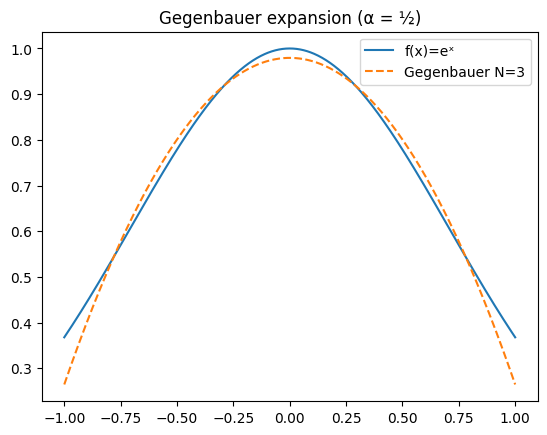

In [16]:
import matplotlib.pyplot as plt

f      = lambda x: np.exp(-x**2)                     # function to expand
alpha  = 1.2                  # α = ½  → Legendre polynomials
N      = 3                          # keep 10 terms
series = gegenbauer_expand(f, N, alpha)
print("Coefficients", series.coeffs)

xs = np.linspace(-1, 1, 2**10)
plt.plot(xs, f(xs),          label="f(x)=eˣ")
plt.plot(xs, series(xs), "--", label=f"Gegenbauer N={N}")
plt.legend()
plt.title("Gegenbauer expansion (α = ½)")
plt.show()




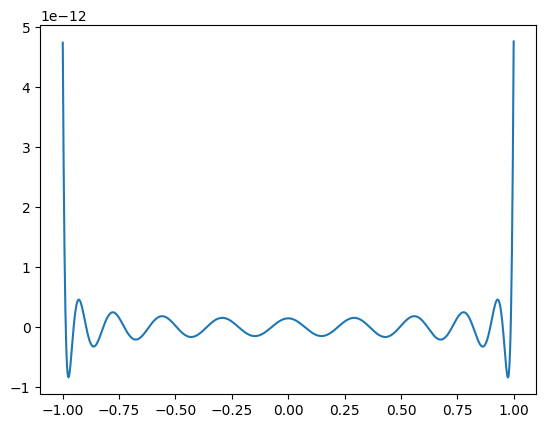

In [12]:
plt.plot(xs, f(xs) - series(xs))